# Notebook 5 — Web: the Flask API and map

The web layer reads the canonical outputs and serves them through a Flask REST API to a MapLibre GL JS map. This notebook queries that API and plays with the turbine performance model. Source: `src/web/app.py` and `src/web/turbines.py`.


## Learning objectives

- Start the web service (Docker or local Python).
- Query layers, resource totals, time series, and hotspots.
- Inspect the turbine dataset and power-curve model.


## 5.1 Start the service

The service is file-oriented: it reads GeoTIFFs, NetCDF, and GeoJSON from an output directory and serves tiles, queries, and downloads.

```bash
docker compose up -d --build        # http://localhost:8001
# or locally:
OUTPUT_DIR=output python -m src.web.app --host 0.0.0.0 --port 5000
```

`docker compose` maps host `8001` to container `5000`. If the service is not running, the cells below fall back to sample responses.


In [1]:
%matplotlib inline
import json
import urllib.request

BASE = 'http://localhost:8001'   # docker compose maps 8001 -> 5000

def get_json(path):
    with urllib.request.urlopen(BASE + path, timeout=3) as r:
        return json.load(r)

try:
    layers = get_json('/api/layers')
    res = get_json('/api/resource?min_power=200')
    print('Connected to', BASE)
    avail = [k for k, v in layers['layers'].items() if v.get('available')]
    print('Available layers:', avail)
    for k in ('n_cells', 'area_km2', 'mean_power_density',
              'extractable_mw', 'aep_gwh_yr'):
        print(f'  {k:22s}: {res.get(k)}')
except Exception as exc:
    print('Web service not running on', BASE, '->', exc)
    print('Start it with:  docker compose up -d --build')
    print('Sample /api/resource response:')
    print(json.dumps({'n_cells': 1559, 'area_km2': 6120.4,
                      'mean_power_density': 412.7,
                      'extractable_mw': 2526.9,
                      'aep_gwh_yr': 22136.1}, indent=2))


Connected to http://localhost:8001
Available layers: ['depth', 'distance', 'power', 'speed']
  n_cells               : 1559
  area_km2              : 6090.637891490627
  mean_power_density    : 395.29
  extractable_mw        : 963022.636
  aep_gwh_yr            : 8436078.293


With the service up, the map opens centred on the archipelago with the **mean power-density** layer as the default overlay — the time-mean ½ρU³ product of the screening run:

![Tidal MSP map overview — mean power density](images/web-map-overview.png)


## 5.2 Endpoints

| Endpoint | Purpose |
|----------|---------|
| `/api/layers` | Layer metadata (bounds, stats, legend, availability) |
| `/api/tiles/{layer}/{z}/{x}/{y}.png` | Colormapped raster tiles |
| `/api/query?lat=&lon=&layer=` | Value at a point |
| `/api/timeseries?lat=&lon=` | Tidal curve from `results.nc` |
| `/api/hotspots?min=&limit=` | Ranked hotspots (GeoJSON) |
| `/api/area_stats` | POST polygon → resource stats |
| `/api/resource` | Filtered-domain totals (area / MW / AEP) |
| `/api/turbines` · `/api/turbine_performance` | Turbine specs & yield |
| `/api/download/{file}` | Download GeoTIFF / GeoJSON / NetCDF |

Dataset-aware endpoints accept `?region=region-001` to target a TELEMAC refinement. `GET /api/datasets` lists what is available.


In [2]:
try:
    ts = get_json('/api/timeseries?lat=12.5&lon=122.5')
    print('site   :', ts.get('lat'), ts.get('lon'))
    print('summary:', ts.get('summary'))
except Exception as exc:
    print('timeseries not available:', exc)

try:
    hots = get_json('/api/hotspots?limit=3')
    print('hotspots returned:', len(hots.get('features', [])))
except Exception as exc:
    print('hotspots not available:', exc)


site   : 12.505608974358976 122.49458083458268
summary: {'max_eta_m': 1.22, 'max_speed_mps': 0.07, 'mean_power_wm2': 0.0, 'mean_speed_mps': 0.01, 'n_points': 361}
hotspots returned: 3


Toggling the other layers shows the same domain through the speed, bathymetry, and distance-to-coast rasters, and the hotspot panel ranks the sites that survived the screening threshold:

![All raster layers overlaid on the map](images/web-map-all-layers.png)

![Ranked hotspot sites in the side panel](images/web-hotspots.png)

The **resource screening** panel (`/api/resource`) aggregates the cells that survive the min-power / depth / efficiency filters into suitable area, extractable MW, and AEP:

![Resource screening totals in the side panel](images/web-resource-screening.png)


## 5.3 Turbine dataset

`src/web/turbines.py` ships a curated set of tidal in-stream turbines with a physically consistent power-curve model (cubic ramp from cut-in to rated speed).


10 turbines loaded
  Kairyu           Kawasaki Heavy Industries     3000 kW  U_rated=2.81 m/s
  O2               Orbital Marine Power          2000 kW  U_rated=2.45 m/s
  AR2000           SIMEC Atlantis Energy         2000 kW  U_rated=3.09 m/s
  ATIR             Magallanes Renovables         1500 kW  U_rated=2.81 m/s
  AR1500           SIMEC Atlantis Energy         1500 kW  U_rated=3.01 m/s


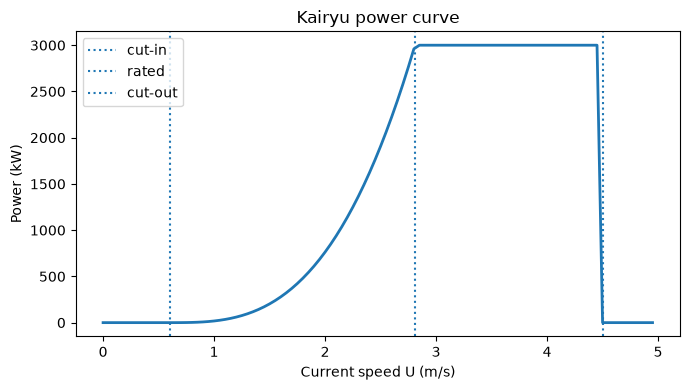

In [3]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from web.turbines import all_turbine_specs
except ImportError as exc:
    print('web.turbines not importable:', exc)
else:
    specs = all_turbine_specs()
    print(f'{len(specs)} turbines loaded')
    for t in specs[:5]:
        print(f"  {t['name']:<16s} {t['manufacturer']:<28s} "
              f"{t['rated_power_kw']:>5.0f} kW  "
              f"U_rated={t['rated_speed_mps']:.2f} m/s")
    top = specs[0]
    pts = np.asarray(top['power_curve'])
    plt.figure(figsize=(7, 4))
    plt.plot(pts[:, 0], pts[:, 1], lw=2)
    for x, lab in [(top['cut_in_mps'], 'cut-in'),
                   (top['rated_speed_mps'], 'rated'),
                   (top['cut_out_mps'], 'cut-out')]:
        plt.axvline(x, ls=':', label=lab)
    plt.xlabel('Current speed U (m/s)')
    plt.ylabel('Power (kW)')
    plt.title(f"{top['name']} power curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


![Power curves of the curated real-turbine fleet.](images/fig_turbine_curves.png)


## 5.4 Site yield

`/api/turbine_performance` (or `web.turbines.performance` directly) integrates a turbine's power series over a site's speed time series to give energy over the window, capacity factor, and AEP.


In [4]:
try:
    from web.turbines import all_turbine_specs, performance
    spec = all_turbine_specs()[0]
    # Synthetic 2-day speed series at a lively site
    rng = np.random.default_rng(3)
    t_h = np.linspace(0, 48, 200)
    speed_ts = 2.0 + 0.6 * np.sin(2 * np.pi * t_h / 12.42) + \
               0.15 * rng.standard_normal(t_h.size)
    perf = performance(spec, [float(x) for x in speed_ts],
                        [float(x) for x in t_h])
    print(f"{spec['name']} over a 2-day synthetic series:")
    print(f"  capacity factor : {perf['capacity_factor'] * 100:.1f} %")
    print(f"  mean output     : {perf['mean_output_kw']:.1f} kW")
    print(f"  AEP             : {perf['aep_gwh_yr']:.3f} GWh/yr")
    print(f"  % time at rated : {perf['pct_time_at_rated']:.1f} %")
except ImportError as exc:
    print('web.turbines not importable:', exc)


Kairyu over a 2-day synthetic series:
  capacity factor : 34.2 %
  mean output     : 1027.1 kW
  AEP             : 8.997 GWh/yr
  % time at rated : 1.0 %


In the map UI the same workflow is one click: the **site inspector** shows the location's stats, the tidal curve from `results.nc`, and the per-turbine yield for the selected device:

![Site inspector: stats, tidal curve, and turbine performance](images/web-site-inspector.png)


## 5.5 Next phase — continuous modelling

Everything so far treats the model as a **snapshot**: the API serves whatever `output/` contains at request time. A production web service should become a **living system** that ingests new bathymetry and tidal observations, re-runs the models, and refreshes the map without a human regenerating every layer. The pieces to add are ingestion, storage, orchestration, and refresh:

| Concern | Open-source tooling |
|---------|---------------------|
| Instrument layer | Tidal gauges, ADCPs, and floats report over MQTT (Eclipse Mosquitto) or the OGC SensorThings API (FROST-Server) |
| Tide-gauge feeds | UNESCO/IOC Sea Level Station Monitoring Facility, NOAA CO-OPS API, IOOS Sensor Observation Service, GLOSS networks |
| Harmonic analysis & QC | pyTMD / utide for constituents, `cf-xarray` + pydap to read remote NetCDF, custom QA gates |
| Storage | TimescaleDB or InfluxDB for observations; Zarr / Kerchunk + STAC (stac-fastapi, pgSTAC) for rasters |
| ETL & scheduling | Apache Airflow / Prefect / Dagster; dbt for repeatable transformations |
| Serving | the existing Flask API + MapLibre map; Grafana for operational dashboards |

A realistic refresh cycle: new **bathymetry** arrives from GEBCO / EMODnet or a multibeam survey (processed with MB-System) and the screening solver re-runs on the updated grid; new **tidal** observations from gauges and IoT sensors are harmonically analysed and folded back into the boundary forcing. The map, time series, and hotspots then drift toward measured reality instead of a one-off snapshot — and the API needs no changes, because the web layer is file-oriented and cache-invalidates on file mtime.

The cell below queries a public tide-gauge feed (NOAA CO-OPS) to show what a live ingestion step looks like. It falls back to a synthetic M2 curve when the network is unavailable.


In [5]:
import json
import urllib.request

# NOAA CO-OPS water-level API (open, free):
# https://api.tidesandcurrents.noaa.gov/api/prod/
station = '8724580'   # Key West, FL — swap for a local gauge
url = ('https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?'
       f'date=recent&station={station}&product=water_level&'
       'units=metric&time_zone=gmt&format=json&interval=6')

try:
    with urllib.request.urlopen(url, timeout=4) as r:
        obs = json.load(r)['data']
    print(f'live water levels @ station {station}: {len(obs)} samples')
    for o in obs[:3]:
        print(f"  t={o['t']}  z={o['v']} m")
except Exception as exc:
    print('live gauge not reachable ->', exc)
    print('synthetic M2 water level instead:')
    t_h = np.arange(0.0, 12.0, 0.1)
    for t in t_h[::12]:
        print(f'  t={t:4.1f} h  z={0.5 * np.cos(2 * np.pi * t / 12.42):+.2f} m')


live gauge not reachable -> HTTP Error 400: Bad Request
synthetic M2 water level instead:
  t= 0.0 h  z=+0.50 m
  t= 1.2 h  z=+0.41 m
  t= 2.4 h  z=+0.17 m
  t= 3.6 h  z=-0.12 m
  t= 4.8 h  z=-0.38 m
  t= 6.0 h  z=-0.50 m
  t= 7.2 h  z=-0.44 m
  t= 8.4 h  z=-0.22 m
  t= 9.6 h  z=+0.07 m
  t=10.8 h  z=+0.34 m


## 5.6 Establishing a turbine array

§ 5.4 sized **one** turbine at a site. An array multiplies that into a field of devices, and the layout is an engineering decision, not a gridding afterthought:

- **Spacing** — devices sit several rotor diameters apart so wakes re-energise before the next rotor: typically **3–5D laterally** and **10–20D streamwise** (D = rotor diameter). Tighter spacing raises blockage and output per m² but cuts efficiency and increases loads.
- **Clearance** — the rotor tip needs a draft below the surface and a gap above the seabed; that rules out parts of even a high-power-density cell.
- **Tidal asymmetry** — flood and ebb often differ in speed and direction, so rows are oriented along the dominant flow axis and devices are pitched or yawed to harvest both phases.
- **Blockage** — the array area ÷ channel cross-section should stay at a few percent or the devices "choke" the strait and change the very flow they harvest.
- **Feedback** — a dense array slows the channel (a momentum sink). The screening solver can represent a first pass by raising the local drag coefficient `cd` in the array cells; later stages use actuator-disk / CFD and farm-layout optimisation (OpenFAST, FLORIS, topfarm).

The cell below packs devices into a rectangular lease block at 4D × 15D spacing and reports installed capacity and annual energy.


In [6]:
try:
    from web.turbines import all_turbine_specs
    spec = all_turbine_specs()[0]   # largest turbine
except ImportError:
    spec = {'name': 'Kairyu', 'rated_power_kw': 3000.0,
            'rotor_diameter_m': 20.0, 'n_rotors': 2}

D = spec['rotor_diameter_m']
S_lat, S_str = 4.0 * D, 15.0 * D    # lateral / streamwise spacing
swept = spec['n_rotors'] * np.pi * (D / 2) ** 2

# A 2 km x 1 km lease block, flow along the 2 km axis
W, L = 2000.0, 1000.0
n_col = max(int(W // S_lat), 1)
n_row = max(int(L // S_str), 1)
n_turb = n_col * n_row
installed_mw = n_turb * spec['rated_power_kw'] / 1e3
cf = 0.30                            # planning-level capacity factor
aep_gwh = installed_mw * cf * 8760.0

print(f"turbine        : {spec['name']} (D = {D:.0f} m)")
print(f'spacing        : {S_lat:.0f} m lateral x {S_str:.0f} m streamwise')
print(f'layout         : {n_col} x {n_row} = {n_turb} devices')
print(f'installed      : {installed_mw:.1f} MW')
print(f'AEP @ CF={cf:.0%} : {aep_gwh:.0f} GWh/yr')
print(f'blockage check : {n_turb * swept / (W * L):.2%} of lease area')


turbine        : Kairyu (D = 20 m)
spacing        : 80 m lateral x 300 m streamwise
layout         : 25 x 3 = 75 devices
installed      : 225.0 MW
AEP @ CF=30% : 591300 GWh/yr
blockage check : 2.36% of lease area


The same area can be assessed interactively in the web app: the **draw tool** turns a polygon into the cell count, area, power-density stats, and extractable MW/AEP for that exact footprint — the geometry-level equivalent of the array block above:

![Polygon site assessment with area statistics](images/web-polygon-assessment.png)


## 5.7 Beyond physics: environment, law, and suitability

Hotspots are physics; a **deployable** site is physics **and** society. The map becomes a marine spatial planning (MSP) tool only once it folds in other factors:

- **Protected areas** — marine protected areas (MPAs), national parks, and no-go zones, from the UNEP-WCMC World Database on Protected Areas (WDPA) / Protected Planet, rasterised into a suitability layer.
- **Other ocean uses** — shipping lanes, fishing grounds (Global Fishing Watch), submarine cables, military zones, and customary use by coastal communities.
- **Ecosystems & species** — coral reefs, seagrass, dugong, cetaceans and migratory corridors (IUCN Red List ranges); construction and operation noise and seabed disturbance.
- **Law & process** — Philippine practice: the NIPAS Act (RA 7586) for MPAs, the Fisheries Code (RA 8550/10654), DOE service contracts and permitting for ocean energy, and an Environmental Impact Statement / Certificate (EIS/ECC) through DENR-EMB before construction, plus public consultation.

Open-source tooling: **geopandas / shapely / rasterio** for the overlay, **QGIS** for interactive review, and **Marxan / prioritizr** for formal conservation-target spatial planning. The output is a **suitability score** per cell that multiplies the resource layer by feasibility masks — the multi-criteria decision-analysis step the MSP literature calls for.

The cell below loads the hotspots and applies a quick suitability filter: anything inside a sample "protected" zone is excluded and the survivors are re-ranked by power density. It falls back to sample data when the model output is not on disk.


In [7]:
import json
from pathlib import Path

root = next((c for c in (Path('.'), Path('../..'))
             if (c / 'src').is_dir()), Path('.'))
hs_path = root / 'output' / 'hotspots.geojson'

try:
    fc = json.loads(hs_path.read_text())
    sites = fc['features']
except Exception:
    print('hotspots.geojson not found; using sample sites')
    def site(lon, lat, power):
        return {'geometry': {'coordinates': [lon, lat]},
                'properties': {'power_density_Wm2': power}}
    sites = [site(122.6, 12.8, 620.0), site(122.3, 12.5, 300.0),
             site(121.9, 12.1, 520.0)]

# Sample protected-zone rectangle (lon/lat). Replace with real
# WDPA polygons in production.
prot = {'west': 122.4, 'east': 122.7, 'south': 12.4, 'north': 12.6}

def inside_protected(s):
    lon, lat = s['geometry']['coordinates']
    return (prot['west'] <= lon <= prot['east']
            and prot['south'] <= lat <= prot['north'])

ranked = sorted((s for s in sites if not inside_protected(s)),
                key=lambda s: s['properties'].get('power_density_Wm2', 0),
                reverse=True)
excluded = sum(inside_protected(s) for s in sites)
print(f'{len(sites)} hotspot(s), {excluded} inside protected zone')
for s in ranked[:3]:
    lon, lat = s['geometry']['coordinates']
    print(f"  P = {s['properties'].get('power_density_Wm2', 0):6.1f} W/m²  "
          f"at ({lat:.2f}, {lon:.2f})")


1559 hotspot(s), 0 inside protected zone
  P = 3080.1 W/m²  at (5.40, 120.66)
  P = 3052.8 W/m²  at (12.49, 124.13)
  P = 2868.5 W/m²  at (5.42, 120.68)


## Next

You have seen the whole stack. Move to [Notebook 6 — consolidation](6.consolidation.ipynb) to recap, run a final stack check, and try the exercises.

---

[Index](README.md) · [← 4.model.ipynb](4.model.ipynb) · [6.consolidation.ipynb →](6.consolidation.ipynb)
